# Full Dataset DBSCAN Parameters and Clustering Evaluation

Parameters tested:  
Bert Base layer 12: eps = 0.13, 0.14, 0.15 & minPts = 100, 1000  
SciBERT layer 11: eps = 0.07, 0.08, 0,09 & minPts = 100, 1000  

Note: Due to limited RAM (~30GB) the DBCV values for cluster partitions on the full dataset could not be computed.

In [ ]:
# Packages
import pandas as pd
import json
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

## Load Full Sample Clustering Results

In [7]:
dfs = []

for filepath in Path("../results/dbscan_full/").glob("*.json"):
    with open(filepath, "r") as f: 
        clustering_results = json.load(f)

    df = pd.DataFrame.from_dict(clustering_results, orient="index")
    #df = df.drop(columns=["labels"])
    df = df.drop(columns=["dbcv"])
    df["file_name"] = filepath
    
    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)

In [13]:
print(all_results.shape)
print(all_results["model"].value_counts())
print(all_results["min_samples"].value_counts())

(12, 12)
model
bert-base    6
scibert      6
Name: count, dtype: int64
min_samples
100     6
1000    6
Name: count, dtype: int64


In [4]:
all_results.groupby(["model", "layer"])["dbcv"].max()

model      layer   
bert-base  layer_12   -1
scibert    layer_11   -1
Name: dbcv, dtype: int64

The allotted memory for this project is not enough compute to calculate the DBCV for a clustering on the full dataset.

## Prepare a LaTeX Table to Export

In [8]:
all_results["noise_pct"] = round(all_results.n_noise / all_results.n_samples, 4) *100
all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct"]].sort_values(["model", "eps"])

,model,layer,eps,min_samples,n_clusters,noise_pct,largest_cluster_pct
0,bert-base,layer_12,0.13,100,7,48.03,51.806727
6,bert-base,layer_12,0.13,1000,2,75.29,22.787916
1,bert-base,layer_12,0.14,100,3,32.77,67.185240
7,bert-base,layer_12,0.14,1000,3,58.85,38.647409
2,bert-base,layer_12,0.15,100,1,20.95,79.050862
8,bert-base,layer_12,0.15,1000,2,41.94,55.852882
3,scibert,layer_11,0.07,1000,2,49.96,49.623294
9,scibert,layer_11,0.07,100,4,33.66,66.255071
4,scibert,layer_11,0.08,1000,1,30.98,69.019722
10,scibert,layer_11,0.08,100,2,20.10,79.883613


In [9]:
print(all_results[["model", "layer", "eps", "min_samples", "n_clusters", "noise_pct", "largest_cluster_pct"]].sort_values(["model", "eps"]).to_latex(
        index=False,
        column_format="llrrr",
        header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
    ))

\begin{tabular}{llrrr}
\toprule
Model & Layer & Epsilon & MinPts & \#Cluster & Noise \% & Largest Cluster \% \\
\midrule
bert-base & layer_12 & 0.130000 & 100 & 7 & 48.030000 & 51.806727 \\
bert-base & layer_12 & 0.130000 & 1000 & 2 & 75.290000 & 22.787916 \\
bert-base & layer_12 & 0.140000 & 100 & 3 & 32.770000 & 67.185240 \\
bert-base & layer_12 & 0.140000 & 1000 & 3 & 58.850000 & 38.647409 \\
bert-base & layer_12 & 0.150000 & 100 & 1 & 20.950000 & 79.050862 \\
bert-base & layer_12 & 0.150000 & 1000 & 2 & 41.940000 & 55.852882 \\
scibert & layer_11 & 0.070000 & 1000 & 2 & 49.960000 & 49.623294 \\
scibert & layer_11 & 0.070000 & 100 & 4 & 33.660000 & 66.255071 \\
scibert & layer_11 & 0.080000 & 1000 & 1 & 30.980000 & 69.019722 \\
scibert & layer_11 & 0.080000 & 100 & 2 & 20.100000 & 79.883613 \\
scibert & layer_11 & 0.090000 & 1000 & 1 & 17.960000 & 82.037480 \\
scibert & layer_11 & 0.090000 & 100 & 1 & 11.700000 & 88.295956 \\
\bottomrule
\end{tabular}



<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\#'
<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\#'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],
/tmp/ipykernel_125058/3907805818.py:4: SyntaxWarning: invalid escape sequence '\%'
  header=["Model", "Layer", "Epsilon", "MinPts", "\#Cluster", "Noise \%", "Largest Cluster \%"],


## Relationship of the Cluster Assignemnt and the Research Field Classification

### Load the Filtered Narrative-Paper Dataset with OpenAlex Enrichment

In [1]:
# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

files_meta = glob.glob("../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files_meta)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files_meta:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                record = json.loads(line)

                records.append({
                    "oa_topics": record.get("oa_topics"),
                    "paperId": record.get("paperId")
                })

            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

oa_df = pd.DataFrame(records)

print(oa_df.shape)
print(oa_df.columns)

Found 4 files
(311686, 2)
Index(['oa_topics', 'paperId'], dtype='str')


#### Extract the Dominant OpenAlex Field

To reduce complexity only one field from the OpenAlex topics is kept. For topics there is a clear ranking, this changes somewhat when increasing the coarsity of the classification. A potential topic to field mapping could look like this:  
topic 1, score: 0.9, field a  
topic 2, score: 0.8, field b  
topic 3, score: 0.3, field a  
The following function by summing the scores would declare field a as the dominant field.
Another option would have been to take the average in this case field b would have been the dominant field, but since the average is outlier sensitive this option was not chosen.

In [2]:
# Solution to reduce the number of research fields to one

def get_dominant_field(topics):
    """
    Identify the dominant and second-most dominant fields from a list of topics.

    Topics are grouped by their ``field`` and ranked according to the sum of
    their topic scores. The field with the highest accumulated score is
    considered the dominant field. For both the dominant and second field,
    the function also calculates the average score across the topics assigned
    to that field.

    Parameters
    ----------
    topics : list of dict
        A list of topic dictionaries. Each dictionary is expected to contain
        a ``field`` key and may contain a ``score`` key. Missing scores
        default to 0.

    Returns
    -------
    pandas.Series
        A Series containing:
        
        - ``dominant_field`` : str or None
            The field with the highest accumulated score.
        - ``dominant_field_score`` : float or int or None
            The sum of scores for the dominant field.
        - ``dominant_field_avg_score`` : float or None
            The average score of topics belonging to the dominant field.
        - ``second_field`` : str or None
            The field with the second-highest accumulated score, if one exists.
        - ``second_field_avg_score`` : float or None
            The average score of topics belonging to the second field.

        If ``topics`` is empty, invalid, or contains no topics with a
        non-null field, all returned values are ``None``.
    """
    if not isinstance(topics, list) or len(topics) == 0:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    field_scores = {}

    for topic in topics:
        field = topic.get("field")
        score = topic.get("score", 0)

        if field is not None:
            field_scores.setdefault(field, []).append(score)

    if not field_scores:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    # Sort fields by their accumulated score
    sorted_fields = sorted(
        field_scores,
        key=lambda field: sum(field_scores[field]),
        reverse=True
    )

    # Dominant field
    dominant_field = sorted_fields[0]
    dominant_scores = field_scores[dominant_field]

    # Second field, if one exists
    if len(sorted_fields) > 1:
        second_field = sorted_fields[1]
        second_scores = field_scores[second_field]
        second_avg_score = sum(second_scores) / len(second_scores)
    else:
        second_field = None
        second_avg_score = None

    return pd.Series({
        "dominant_field": dominant_field,
        "dominant_field_score": sum(dominant_scores),
        "dominant_field_avg_score": sum(dominant_scores) / len(dominant_scores),
        "second_field": second_field,
        "second_field_avg_score": second_avg_score
    })

# Decide on the dominant field (if there there is more than one possible field) 
oa_df[
    [
        "dominant_field",
        "dominant_field_score",
        "dominant_field_avg_score",
        "second_field",
        "second_field_avg_score"
    ]
] = oa_df["oa_topics"].apply(get_dominant_field)

### Load the Narrative-Mentions Dataset

In [43]:
pop_file = "../data/mentions/narrative_mentions.jsonl"

records = []

with open(pop_file, "r", encoding="utf-8") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Skipping malformed line in {pop_file}")

mentions_df = pd.DataFrame(records)

print(mentions_df.shape)
print(mentions_df.columns)


mentions_df = mentions_df[['paperId', 'text_type', 'id', 'text_cleaned']] # Free up RAM

print(mentions_df.shape)
print(mentions_df.columns)

(537645, 15)
Index(['paperId', 'doi', 'oa_id', 'text_type', 'text_cleaned', 'match_type',
       'matched_seq', 'matched_char_start', 'matched_char_end', 'sentence_pos',
       'pos', 'id', 'context_token_ids', 'context_n_tokens',
       'matched_token_indices'],
      dtype='str')
(537645, 4)
Index(['paperId', 'text_type', 'id', 'text_cleaned'], dtype='str')


### Merge the Narrative-Paper and the Narrative-Mentions Dataset

In [44]:
merged_df = mentions_df.merge(
    oa_df,
    on="paperId",
    how="left"
)

print(oa_df["paperId"].duplicated().sum())

0


### Load the Clustering Partitioning with the Most Promising Clustering Features
SciBERT, minPts = 100 & epsilon = 0.07

In [45]:
best = all_results[(all_results.model == "scibert") & (all_results.min_samples == 100) & (all_results.eps == 0.07)]
best["labels"]

9    {'103343': 0, '103344': -1, '103345': 0, '1033...
Name: labels, dtype: object

In [46]:
labels_df = pd.DataFrame(
    best["labels"].iloc[0].items(),
    columns=["id", "cluster"]
)

labels_df["id"] = labels_df["id"].astype(int)

labels_df.head()

,id,cluster
0,103343,0
1,103344,-1
2,103345,0
3,103346,0
4,103347,-1


In [26]:
type(labels_df.id.iloc[0])

numpy.int64

### Merge the Cluster Assignments to the Narrative-Mentions Dataset Enhanced with Features from the Narrative-Paper Dataset

In [47]:
merged_df_all = merged_df.merge(
    labels_df,
    on="id",
    how="left"
)

In [48]:
merged_df_all.head()

,paperId,text_type,id,text_cleaned,oa_topics,dominant_field,dominant_field_score,dominant_field_avg_score,second_field,second_field_avg_score,cluster
0,0000278bfcd5dfc1d586156ccff16e168f238e83,title,0,reading contemporary black british and african...,"[{'id': 'https://openalex.org/T11717', 'displa...",Arts and Humanities,0.9700,0.97000,NaN,NaN,-1.0
1,0000278bfcd5dfc1d586156ccff16e168f238e83,abstract,1,"in their introduction, wyatt and george expres...","[{'id': 'https://openalex.org/T11717', 'displa...",Arts and Humanities,0.9700,0.97000,NaN,NaN,0.0
2,4aae5a329915daacf79c4354ec5c72d136424348,abstract,2,the authors show how visual culture has been e...,"[{'id': 'https://openalex.org/T13256', 'displa...",Social Sciences,1.8446,0.92230,NaN,NaN,-1.0
3,4aaeb618b4e06b682c54f3db0eace3690b07c01a,title,3,vocabulary diversity in personal narratives pr...,"[{'id': 'https://openalex.org/T10103', 'displa...",Psychology,0.8421,0.42105,Neuroscience,0.0823,-1.0
4,4aaeb618b4e06b682c54f3db0eace3690b07c01a,abstract,4,introduction: this study examines whether ther...,"[{'id': 'https://openalex.org/T10103', 'displa...",Psychology,0.8421,0.42105,Neuroscience,0.0823,0.0


In [30]:
merged_df_all.columns

Index(['paperId', 'text_type', 'id', 'oa_topics', 'dominant_field',
       'dominant_field_score', 'dominant_field_avg_score', 'second_field',
       'second_field_avg_score', 'cluster'],
      dtype='str')

### Plot the Distribution of the Dominant Research Field for each Mention across Clusters

In [ ]:
# Count Mentions per field and cluster
counts = (
    merged_df_all
    .groupby(["dominant_field", "cluster"])
    .size()
    .reset_index(name="count")
)

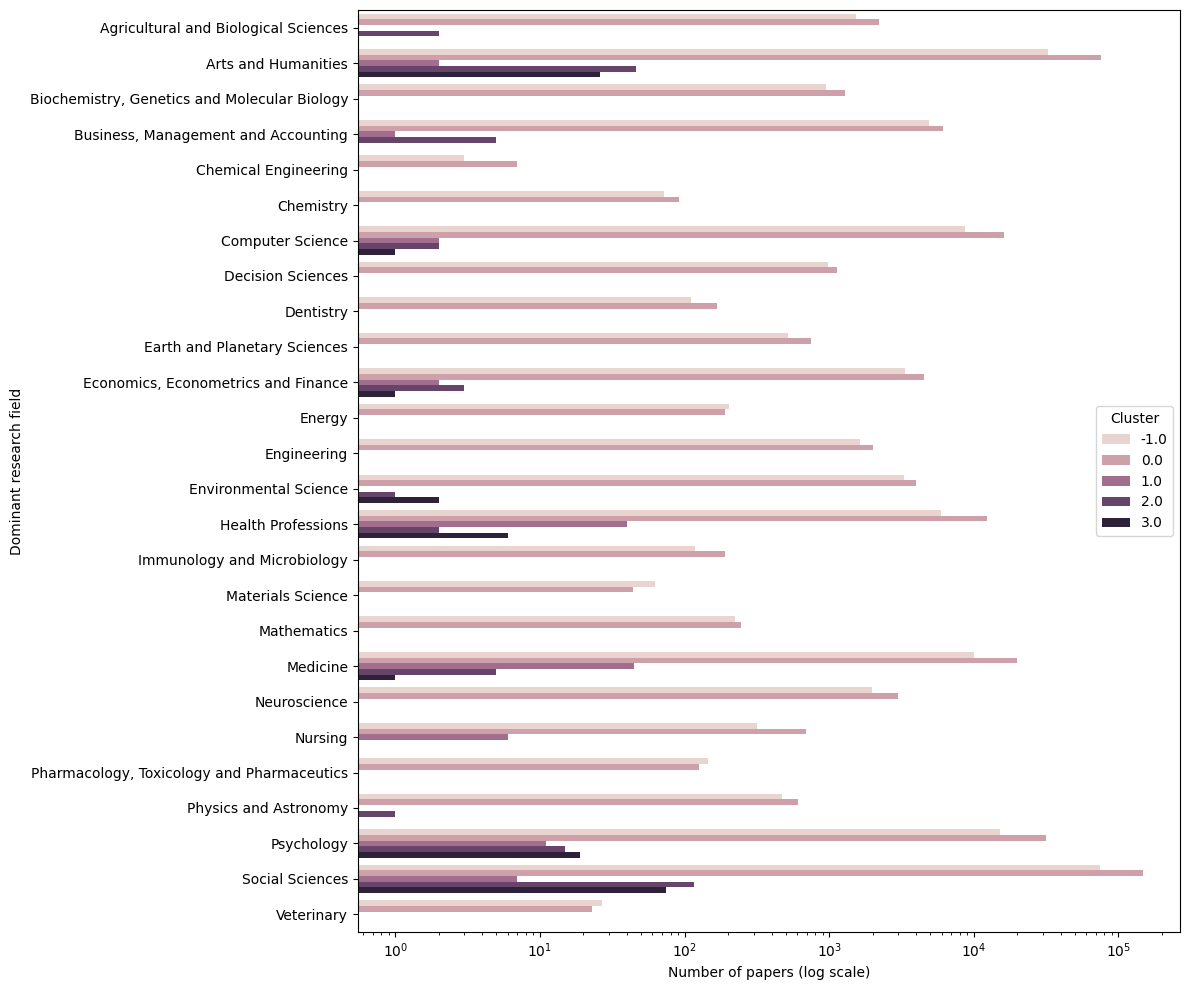

In [35]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=counts,
    x="count",
    y="dominant_field",
    hue="cluster",
)

plt.xscale("log")

plt.xlabel("Number of mentions (log scale)")
plt.ylabel("Dominant research field")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

### Plot the Distribution of the Dominant Research Field for each Text Type (Title vs Abstract) across Clusters

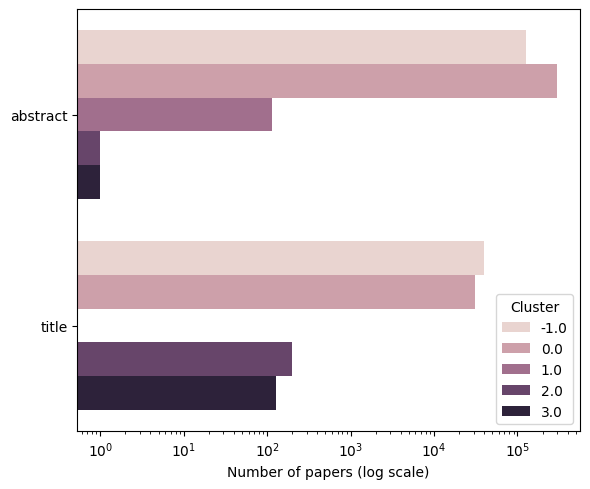

In [40]:
# Count mentions per text type and cluster
counts = (
    merged_df_all
    .groupby(["text_type", "cluster"])
    .size()
    .reset_index(name="count")
)
plt.figure(figsize=(6, 5))

sns.barplot(
    data=counts,
    x="count",
    y="text_type",
    hue="cluster",
)

plt.xscale("log")

plt.xlabel("Number of papers (log scale)")
plt.ylabel("")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

Mentions assigned to cluster one are exclusively from abstracts.  
Mentions assigned to cluster two and three are more likely to be from a title.  
Note that cluster one to three are barely over 100 mentions and therewith very close to the cutoff minPts value defined for this clustering.  
Cluster zero and noise are prevelant in mentions from both text types.  
Most mentions from the title are classified as noise, whilest for the abstract they are mostly classified as belonging to cluster zero.

#### Version Without Log-Scale for the Count of Mentions

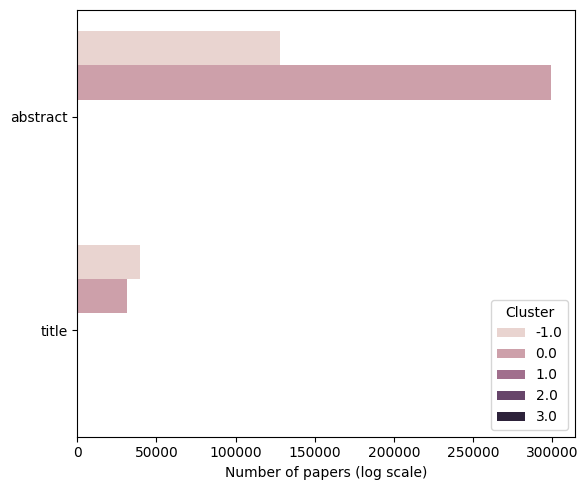

In [41]:
# Count papers per field and cluster
counts = (
    merged_df_all
    .groupby(["text_type", "cluster"])
    .size()
    .reset_index(name="count")
)
plt.figure(figsize=(6, 5))

sns.barplot(
    data=counts,
    x="count",
    y="text_type",
    hue="cluster",
)

#plt.xscale("log")

plt.xlabel("Number of papers (log scale)")
plt.ylabel("")
#plt.title("Distribution of dominant research fields across clusters")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

### Cluster-Specific Top TF-IDF N-grams

In [49]:
top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    top_indices = scores.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (terms[i], scores[i])
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, score in ngrams:
        print(f"{ngram:40s} {score:.4f}")


Cluster -1.0
narrative                                0.0242
narratives                               0.0204
study                                    0.0061
analysis                                 0.0052
research                                 0.0050
social                                   0.0049
based                                    0.0043
data                                     0.0039
new                                      0.0039
article                                  0.0038

Cluster 0.0
narrative                                0.0235
narratives                               0.0185
study                                    0.0070
analysis                                 0.0070
research                                 0.0055
article                                  0.0048
using                                    0.0043
data                                     0.0043
approach                                 0.0042
social                                   0.0041

Cluster 1.0


#### Variation with Longer N-Grams

In [51]:
top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = TfidfVectorizer(
        ngram_range=(2, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    # Keep only n-grams containing "narrative" or "narratives"
    mask = [
        any(word in {"narrative", "narratives"} for word in term.split())
        for term in terms
    ]

    filtered_terms = terms[mask]
    filtered_scores = scores[mask]

    # Top 10
    top_indices = filtered_scores.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (filtered_terms[i], filtered_scores[i])
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, score in ngrams:
        print(f"{ngram:40s} {score:.4f}")


Cluster -1.0
historical narrative                     0.0014
counter narratives                       0.0013
counter narrative                        0.0013
historical narratives                    0.0011
narrative analysis                       0.0011
personal narrative                       0.0011
personal narratives                      0.0010
master narrative                         0.0009
media narratives                         0.0008
life narratives                          0.0008

Cluster 0.0
narrative analysis                       0.0031
narrative inquiry                        0.0030
narrative structure                      0.0020
narrative approach                       0.0020
narrative text                           0.0019
using narrative                          0.0016
historical narratives                    0.0015
historical narrative                     0.0013
personal narratives                      0.0013
narrative form                           0.0012

Cluster 1.0


#### Manually Check Mentions in Cluster One (narrative evidence synthes[ie]s)

In [53]:
merged_df_all[merged_df_all.cluster == 1.0].text_cleaned

1101      selection and appraisal of documents were base...
2081      we employed pawson and tilley’s realist review...
6600      methods and analysis this realist review will ...
9724      findings will be presented in accordance with ...
17439     methods and analysis the protocol has been reg...
                                ...                        
514200    results will be written according to the rames...
517088    the results will be published in accordance wi...
520077    the review follows the guidelines presented by...
522253    methods this was a realist review reported fol...
534898    following realist and meta-narrative evidence ...
Name: text_cleaned, Length: 116, dtype: str

#### Variation With Long N-Grams and Count instead of TF-IDF

In [54]:
top_ngrams = {}

for cluster, group in merged_df_all.groupby("cluster"):
    texts = group["text_cleaned"].fillna("").astype(str)

    vectorizer = CountVectorizer(
        ngram_range=(2, 3),
        min_df=2,
        max_df=0.95,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    terms = vectorizer.get_feature_names_out()

    # Keep only n-grams containing "narrative" or "narratives"
    mask = [
        any(word in {"narrative", "narratives"} for word in term.split())
        for term in terms
    ]

    filtered_terms = terms[mask]
    filtered_counts = X[:, mask].sum(axis=0).A1

    # Top 10 by actual occurrence count
    top_indices = filtered_counts.argsort()[::-1][:10]

    top_ngrams[cluster] = [
        (filtered_terms[i], int(filtered_counts[i]))
        for i in top_indices
    ]

# Display
for cluster, ngrams in top_ngrams.items():
    print(f"\nCluster {cluster}")
    for ngram, count in ngrams:
        print(f"{ngram:40s} {count}")


Cluster -1.0
narrative time                           1435
historical narrative                     1298
narrative analysis                       1289
counter narrative                        1193
counter narratives                       1192
historical narratives                    1054
master narrative                         1037
narrative text                           1033
narrative time nero                      1026
non narrative                            1019

Cluster 0.0
narrative analysis                       7559
narrative inquiry                        7319
narrative text                           4786
narrative structure                      4548
narrative approach                       4150
using narrative                          3556
historical narratives                    3089
personal narratives                      2554
narrative texts                          2401
historical narrative                     2370

Cluster 1.0
narrative evidence syntheses            

No clear patterns beside cluster one (which seems to have been overlooked during the narrative review exclusion step)